In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from scipy import stats
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn import preprocessing
from sklearn.model_selection import train_test_split

**Procrastination and Social media usage among University students Dataset**

1.  Import the data (data project (Responses) - Form Responses 1.csv)





In [4]:
from google.colab import files
upload = files.upload()

Saving data project (Responses) - Form Responses 1.csv to data project (Responses) - Form Responses 1.csv





2.   Read the head of the csv file



In [5]:
df = pd.read_csv("data project (Responses) - Form Responses 1.csv")
df.head()

,Timestamp,1. What is your academic year?,"2. On average, how many hours per day do you spend on social media?",3. Which social media platform do you use the most?,4.How often do you check social media while studying?\n,5. How often do you delay starting your academic tasks?,6. How often do you leave assignments until the last minute?,7. How would you rate your level of procrastination?,8. What do you most commonly do instead of completing a task?,9. Do you think social media affects your productivity?,"10. On a scale of 1–5, how much does social media negatively impact your ability to focus?"
0,4/6/2026 17:20:00,2nd Year,5–6 hours,TikTok,Often,Often,Always,4,Scroll on social media,Yes,4
1,4/6/2026 17:27:01,5th Year,5–6 hours,TikTok,Always,Rarely,Rarely,3,Scroll on social media,Maybe,4
2,4/6/2026 17:29:49,4th Year,3–4 hours,Instagram,Sometimes,Sometimes,Never,3,Scroll on social media,Yes,5
3,4/6/2026 17:30:06,2nd Year,More than 6 hours,TikTok,Always,Always,Often,5,Scroll on social media,Yes,5
4,4/6/2026 17:34:19,2nd Year,3–4 hours,LinkedIn,Sometimes,Sometimes,Always,2,Extracurricular,Yes,4





3. Checking the shape



In [ ]:
print(f"Total responses: {df.shape[0]}")
print(f"Total columns: {df.shape[1]}")

Total responses: 110
Total columns: 11


4. Dimentions of the dataset

In [ ]:
print("Dimensions:", df.shape)
print(df.info())

Dimensions: (110, 11)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 110 entries, 0 to 109
Data columns (total 11 columns):
 #   Column                                                                                       Non-Null Count  Dtype 
---  ------                                                                                       --------------  ----- 
 0   Timestamp                                                                                    110 non-null    object
 1   1. What is your academic year?                                                               110 non-null    object
 2   2. On average, how many hours per day do you spend on social media?                          110 non-null    object
 3   3. Which social media platform do you use the most?                                          110 non-null    object
 4   4.How often do you check social media while studying?
                                       110 non-null    object
 5   5. How often do you d




5. The data types of the columns:



In [ ]:
print(df.dtypes)

Timestamp                                                                                      object
1. What is your academic year?                                                                 object
2. On average, how many hours per day do you spend on social media?                            object
3. Which social media platform do you use the most?                                            object
4.How often do you check social media while studying?\n                                        object
5. How often do you delay starting your academic tasks?                                        object
6. How often do you leave assignments until the last minute?                                   object
7. How would you rate your level of procrastination?                                            int64
8. What do you most commonly do instead of completing a task?                                  object
9. Do you think social media affects your productivity?                           



6.  Checking for missing values




In [ ]:
df.isnull().sum()


,0
Timestamp,0
1. What is your academic year?,0
"2. On average, how many hours per day do you spend on social media?",0
3. Which social media platform do you use the most?,0
4.How often do you check social media while studying?\n,0
5. How often do you delay starting your academic tasks?,0
6. How often do you leave assignments until the last minute?,0
7. How would you rate your level of procrastination?,0
8. What do you most commonly do instead of completing a task?,0
9. Do you think social media affects your productivity?,0




7.  See all column names


In [ ]:
df.columns.tolist()


['Timestamp',
 '1. What is your academic year?',
 '2. On average, how many hours per day do you spend on social media?',
 '3. Which social media platform do you use the most?',
 '4.How often do you check social media while studying?\n',
 '5. How often do you delay starting your academic tasks?',
 '6. How often do you leave assignments until the last minute?',
 '7. How would you rate your level of procrastination?',
 '8. What do you most commonly do instead of completing a task?',
 '9. Do you think social media affects your productivity?',
 '10.  On a scale of 1–5, how much does social media negatively impact your ability to focus?']

**Step 2 : Data Cleaning**


1.   Rename columns to shorter, cleaner names List item




In [7]:
# Short names make coding easier and charts cleaner.
df.columns = [
    'Timestamp',
    'Academic_Year',
    'Hours_Social_Media',
    'Most_Used_Platform',
    'Check_SM_While_Studying',
    'Delay_Starting_Tasks',
    'Last_Minute_Assignments',
    'Procrastination_Rating',
    'Activity_Instead_of_Task',
    'SM_Affects_Productivity',
    'Negative_Impact_Focus'
]
df.head()


,Timestamp,Academic_Year,Hours_Social_Media,Most_Used_Platform,Check_SM_While_Studying,Delay_Starting_Tasks,Last_Minute_Assignments,Procrastination_Rating,Activity_Instead_of_Task,SM_Affects_Productivity,Negative_Impact_Focus
0,4/6/2026 17:20:00,2nd Year,5–6 hours,TikTok,Often,Often,Always,4,Scroll on social media,Yes,4
1,4/6/2026 17:27:01,5th Year,5–6 hours,TikTok,Always,Rarely,Rarely,3,Scroll on social media,Maybe,4
2,4/6/2026 17:29:49,4th Year,3–4 hours,Instagram,Sometimes,Sometimes,Never,3,Scroll on social media,Yes,5
3,4/6/2026 17:30:06,2nd Year,More than 6 hours,TikTok,Always,Always,Often,5,Scroll on social media,Yes,5
4,4/6/2026 17:34:19,2nd Year,3–4 hours,LinkedIn,Sometimes,Sometimes,Always,2,Extracurricular,Yes,4





2. Drop the Timestamp column (not needed for analysis)



In [ ]:
df = df.drop(columns=['Timestamp'])
df.head()


,Academic_Year,Hours_Social_Media,Most_Used_Platform,Check_SM_While_Studying,Delay_Starting_Tasks,Last_Minute_Assignments,Procrastination_Rating,Activity_Instead_of_Task,SM_Affects_Productivity,Negative_Impact_Focus
0,2nd Year,5–6 hours,TikTok,Often,Often,Always,4,Scroll on social media,Yes,4
1,5th Year,5–6 hours,TikTok,Always,Rarely,Rarely,3,Scroll on social media,Maybe,4
2,4th Year,3–4 hours,Instagram,Sometimes,Sometimes,Never,3,Scroll on social media,Yes,5
3,2nd Year,More than 6 hours,TikTok,Always,Always,Often,5,Scroll on social media,Yes,5
4,2nd Year,3–4 hours,LinkedIn,Sometimes,Sometimes,Always,2,Extracurricular,Yes,4





3. Standardize the platform names (the computer treats them as different values so to ensure consistency )



In [ ]:
df['Most_Used_Platform'] = df['Most_Used_Platform'].str.strip().str.title()
df['Most_Used_Platform'] = df['Most_Used_Platform'].replace({
    'Whatsapp , Youtube': 'Other',
    'Reddit': 'Other',
    'Snapchat':'Other',
    'Linkedin':'Other',
    'All': 'Other'
})
df['Most_Used_Platform'].value_counts()


,count
Most_Used_Platform,
Tiktok,61
Instagram,38
Other,5
Facebook,4
Twitter (X),2





4. Verify the cleaned data



In [ ]:
print("Missing values:")
print(df.isnull().sum())
print(f"\nDuplicate rows: {df.duplicated().sum()}")
print(f"\nShape: {df.shape}")


Missing values:
Academic_Year               0
Hours_Social_Media          0
Most_Used_Platform          0
Check_SM_While_Studying     0
Delay_Starting_Tasks        0
Last_Minute_Assignments     0
Procrastination_Rating      0
Activity_Instead_of_Task    0
SM_Affects_Productivity     0
Negative_Impact_Focus       0
dtype: int64

Duplicate rows: 1

Shape: (110, 10)




5.  Remove Duplicate Row




In [ ]:
df = df.drop_duplicates()
print("Shape after removing duplicates:", df.shape)


Shape after removing duplicates: (109, 10)


**Step 3 : Descriptive Statistics**

1. Descriptive Stats for Numeric Columns




In [ ]:
# Convert Hours_Social_Media to numeric
mapping = {
    "Less than 1 hour": 0.5,
    "1–2 hours": 1.5,
    "3–4 hours": 3.5,
    "5–6 hours": 5.5,
    "More than 6 hours": 7
}
df['Hours_Social_Media'] = df['Hours_Social_Media'].map(mapping)

# Now calculate stats
numeric_cols = ['Hours_Social_Media', 'Procrastination_Rating', 'Negative_Impact_Focus']

for col in numeric_cols:
    print(f"--- {col} ---")
    print(f"  Mean:   {df[col].mean():.2f}")
    print(f"  Median: {df[col].median():.2f}")
    print(f"  Mode:   {df[col].mode()[0]}")
    print()

--- Hours_Social_Media ---
  Mean:   4.41
  Median: 3.50
  Mode:   3.5

--- Procrastination_Rating ---
  Mean:   3.58
  Median: 4.00
  Mode:   3

--- Negative_Impact_Focus ---
  Mean:   3.98
  Median: 4.00
  Mode:   4






2.  Frequency Counts for Categorical Columns



In [ ]:
cat_cols = ['Most_Used_Platform', 'Check_SM_While_Studying',
            'Delay_Starting_Tasks', 'Last_Minute_Assignments',
            'Activity_Instead_of_Task', 'SM_Affects_Productivity']

for col in cat_cols:
    print(f"--- {col} ---")
    print(df[col].value_counts())
    print()


--- Most_Used_Platform ---
Most_Used_Platform
Tiktok         60
Instagram      38
Other           5
Facebook        4
Twitter (X)     2
Name: count, dtype: int64

--- Check_SM_While_Studying ---
Check_SM_While_Studying
Often        38
Always       30
Sometimes    30
Rarely        7
Never         4
Name: count, dtype: int64

--- Delay_Starting_Tasks ---
Delay_Starting_Tasks
Sometimes    39
Often        34
Always       28
Rarely        7
Never         1
Name: count, dtype: int64

--- Last_Minute_Assignments ---
Last_Minute_Assignments
Always       39
Often        32
Sometimes    23
Rarely       10
Never         5
Name: count, dtype: int64

--- Activity_Instead_of_Task ---
Activity_Instead_of_Task
Scroll on social media    57
Watch videos              23
Sleep/rest                14
Talk to friends/family    11
All                        2
Extracurricular            1
All of them                1
Name: count, dtype: int64

--- SM_Affects_Productivity ---
SM_Affects_Productivity
Yes      8

**Step 4: Data Visualization**


* Chart 1 — Bar Chart: Most Used Social Media Platform






Why this chart? A bar chart is best for comparing counts across categories. It shows which platforms dominate among your respondents.

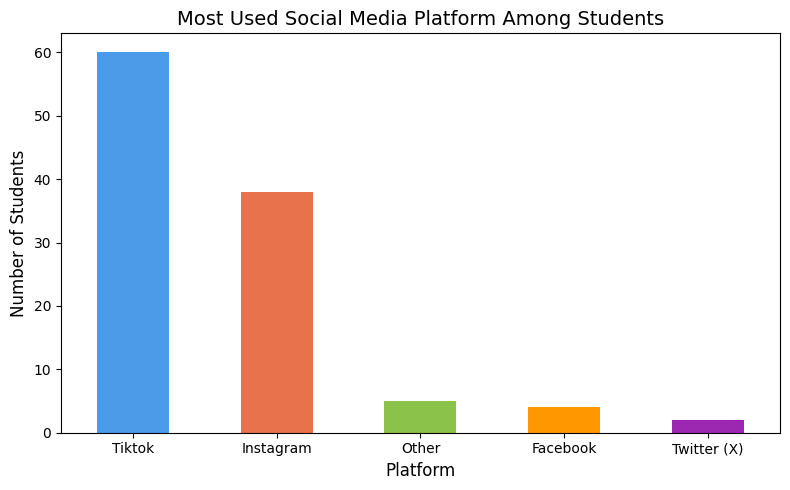

In [ ]:

platform_counts = df['Most_Used_Platform'].value_counts()

plt.figure(figsize=(8, 5))
platform_counts.plot(kind='bar', color=['#4C9BE8', '#E8724C', '#8BC34A', '#FF9800', '#9C27B0'])
plt.title('Most Used Social Media Platform Among Students', fontsize=14)
plt.xlabel('Platform', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart1_platform.png', dpi=150)
plt.show()

The majority of respondents (60 out of 109) reported TikTok as their most-used social media platform, followed by Instagram (38 students). This suggests that short-form video platforms are the dominant form of social media consumption among university students in this sample.




**Chart 2 - Pie Chart : Does Social Media Affect Productivity?**





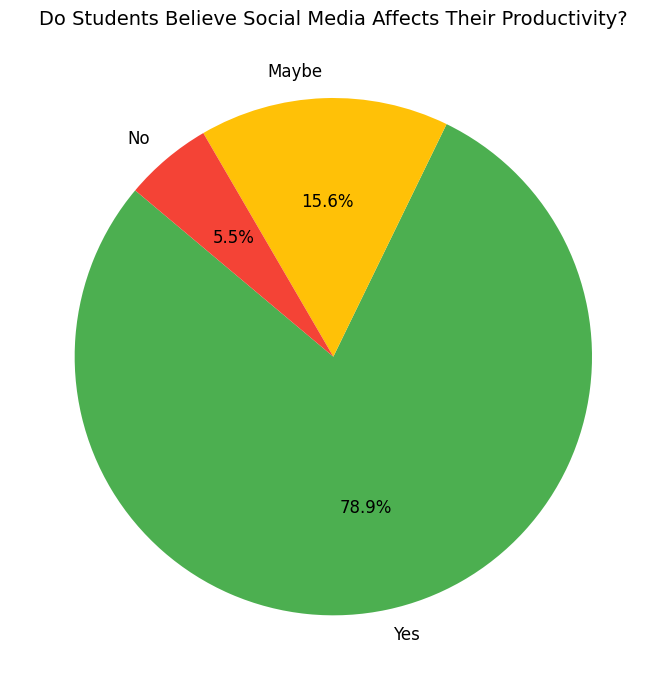

In [ ]:
productivity_counts = df['SM_Affects_Productivity'].value_counts()

plt.figure(figsize=(7, 7))
colors = ['#4CAF50', '#FFC107', '#F44336']
plt.pie(productivity_counts, labels=productivity_counts.index, autopct='%1.1f%%',
        colors=colors, startangle=140, textprops={'fontsize': 12})
plt.title('Do Students Believe Social Media Affects Their Productivity?', fontsize=14)
plt.tight_layout()
plt.savefig('chart2_productivity.png', dpi=150)
plt.show()

An overwhelming 78.9% of students agreed that social media affects their productivity, while only 5.5% said it does not. This indicates a strong self-awareness among students that their social media habits negatively influence their academic performance.

**Chart 3 -  Bar Chart: How Often Students Check Social Media While Studying**

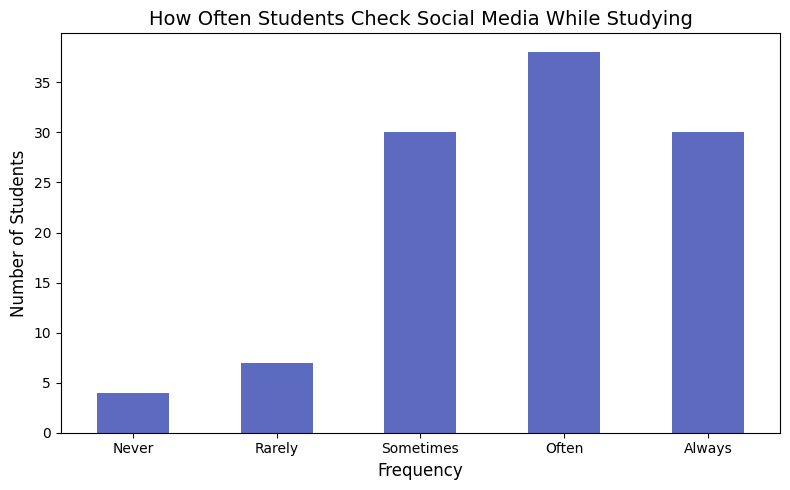

In [ ]:
order = ['Never', 'Rarely', 'Sometimes', 'Often', 'Always']
check_counts = df['Check_SM_While_Studying'].value_counts().reindex(order)

plt.figure(figsize=(8, 5))
check_counts.plot(kind='bar', color='#5C6BC0')
plt.title('How Often Students Check Social Media While Studying', fontsize=14)
plt.xlabel('Frequency', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('chart3_check_while_studying.png', dpi=150)
plt.show()

The majority of students check social media 'Often' (38) or 'Always' (30) while studying, with only 4 students reporting 'Never.' This shows that social media is a persistent distraction during study time for the vast majority of respondents."

**Chart 4  — Histogram: Procrastination Rating Distribution**

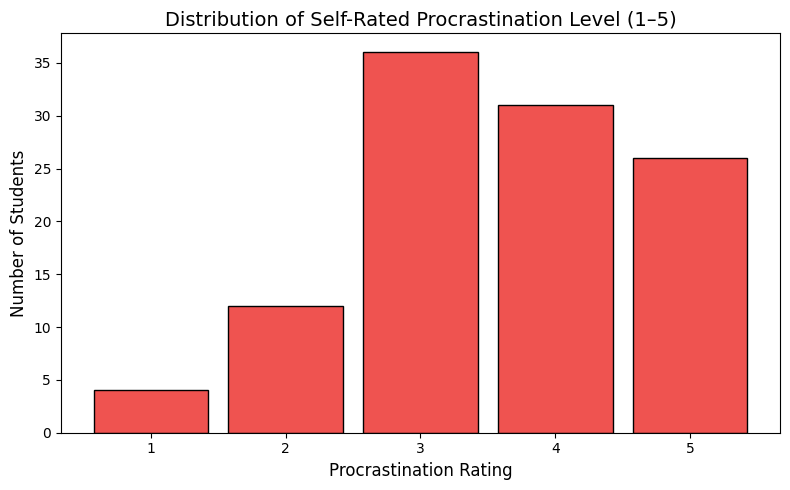

In [ ]:

plt.figure(figsize=(8, 5))
plt.hist(df['Procrastination_Rating'], bins=[0.5, 1.5, 2.5, 3.5, 4.5, 5.5],
         color='#EF5350', edgecolor='black', rwidth=0.85)
plt.title('Distribution of Self-Rated Procrastination Level (1–5)', fontsize=14)
plt.xlabel('Procrastination Rating', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.tight_layout()
plt.savefig('chart4_procrastination_dist.png', dpi=150)
plt.show()


Why histogram? It shows the distribution/spread of a numeric variable.

The distribution of procrastination ratings is skewed towards higher values, with ratings of 3, 4, and 5 being the most common. The mean procrastination rating is 3.58 out of 5, indicating that most students perceive themselves as moderate-to-high procrastinators.

**Chart 5 — Grouped Bar Chart: Social Media Hours vs. Average Procrastination Rating  (KEY CHART for the hypothesis!)**

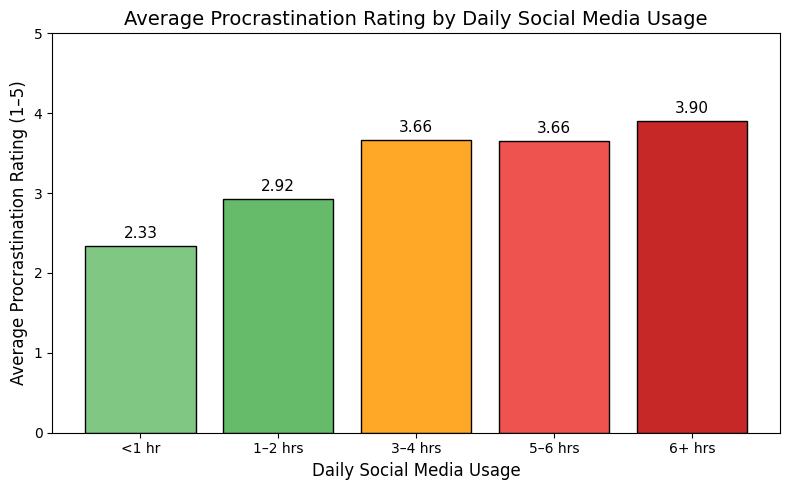

In [ ]:
hours_order = [0.5, 1.5, 3.5, 5.5, 7.0]
hours_labels = ['<1 hr', '1–2 hrs', '3–4 hrs', '5–6 hrs', '6+ hrs']

avg_proc = df.groupby('Hours_Social_Media')['Procrastination_Rating'].mean().reindex(hours_order)

plt.figure(figsize=(8, 5))
bars = plt.bar(hours_labels, avg_proc, color=['#81C784', '#66BB6A', '#FFA726', '#EF5350', '#C62828'],
               edgecolor='black')
plt.title('Average Procrastination Rating by Daily Social Media Usage', fontsize=14)
plt.xlabel('Daily Social Media Usage', fontsize=12)
plt.ylabel('Average Procrastination Rating (1–5)', fontsize=12)
plt.ylim(0, 5)

# Add value labels on top of each bar
for bar, val in zip(bars, avg_proc):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
             f'{val:.2f}', ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('chart5_hours_vs_procrastination.png', dpi=150)
plt.show()

Why this chart? It directly tests your hypothesis by showing whether higher social media usage correlates with higher procrastination.

There is a general upward trend in average procrastination rating as daily social media usage increases. Students who use social media for more than 6 hours per day have a noticeably higher average procrastination rating compared to those who use it for less than 1 hour. This pattern supports the hypothesis that higher social media usage is associated with greater procrastination among university students.

**Chart 6 — Bar Chart: What Students Do Instead of Completing Task**

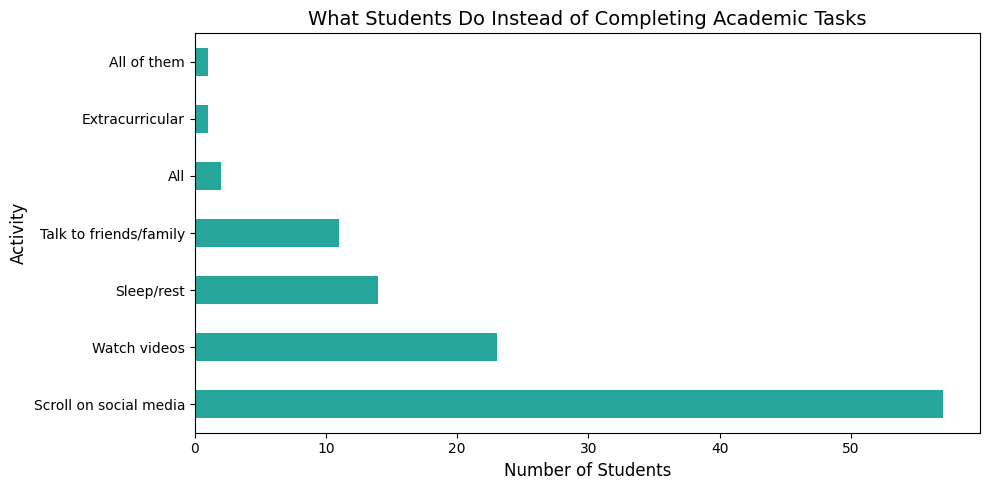

In [ ]:
activity_counts = df['Activity_Instead_of_Task'].value_counts()

plt.figure(figsize=(10, 5))
activity_counts.plot(kind='barh', color='#26A69A')
plt.title('What Students Do Instead of Completing Academic Tasks', fontsize=14)
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('Activity', fontsize=12)
plt.tight_layout()
plt.savefig('chart6_distraction_activity.png', dpi=150)
plt.show()

# Bar Chart Showing Academic year & Number of students

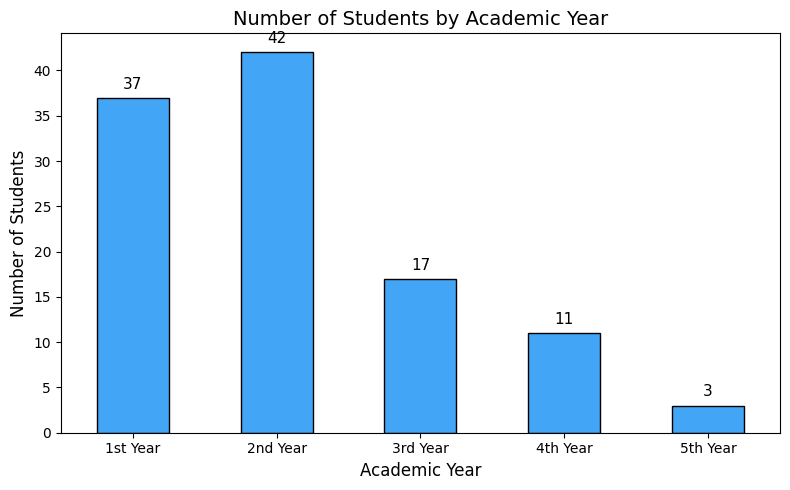

In [8]:
# Chart: Number of Students by Academic Year


year_counts = df['Academic_Year'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
year_counts.plot(kind='bar', color='#42A5F5', edgecolor='black')
plt.title('Number of Students by Academic Year', fontsize=14)
plt.xlabel('Academic Year', fontsize=12)
plt.ylabel('Number of Students', fontsize=12)
plt.xticks(rotation=0)

# Add value labels on top
for i, v in enumerate(year_counts):
    plt.text(i, v + 1, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.savefig('chart_academic_year.png', dpi=150)
plt.show()


More than half of the respondents (57 students) reported scrolling on social media as their primary procrastination activity, followed by watching videos (23 students). This reinforces the connection between social media and procrastination, as social media itself is the leading distraction that replaces academic tasks

**Step 5 :  Insights & Hypothesis Testing**



*  Higher social media usage = higher procrastination — Chart 5 shows a clear upward trend in average procrastination rating as daily hours increase. This directly supports your hypothesis.


*   Social media is the #1 distraction — Chart 6 shows that 57 out of 109 students scroll social media instead of completing tasks, confirming that SM is not just correlated with procrastination but is the primary vehicle for it.

*   Students are self-aware but not changing behavior — 78.9% (Chart 2) acknowledge SM hurts productivity, yet 62% check it "Often" or "Always" while studying (Chart 3). This gap between awareness and action is a significant finding.



*  TikTok dominates — Chart 1 shows TikTok (60 students) as the leading platform, suggesting short-form video content may be especially addictive and disruptive to focus.


*  Procrastination is widespread — The mean rating of 3.58/5 and the right-skewed distribution (Chart 4) show most students rate themselves as moderate-to-high procrastinators.








**Hypothesis Verdict**

# **Hypothesis: "Students who spend more time on social media are more likely to procrastinate on academic tasks.**

Finding: SUPPORTED. The data shows a positive relationship between daily social media usage and self-reported procrastination. Students using SM 6+ hours scored higher on procrastination than those using it <1 hour. Additionally, 78.9% of respondents confirmed SM negatively affects their productivity, and the most common distraction activity was scrolling social media.

Important caveat: This is a correlational finding based on self-reported survey data. We cannot conclude that social media causes procrastination — other factors (stress, poor time management) may also contribute.